In [26]:
import os
import cv2
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from pathlib import Path
import albumentations as A
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.model_selection import train_test_split

In [27]:
# RGB path
rgbPath = f"./20250411/RGB"

rgbPath

'./20250411/RGB'

In [28]:
#Load dataset
images = list(Path(rgbPath).glob("*.JPG"))
labels = list(Path(rgbPath).glob("*.txt"))

print("Total images:", len(images))
print("Total labels:", len(labels))

Total images: 1127
Total labels: 1126


##Visualize Sample Images

(np.float64(-0.5), np.float64(5279.5), np.float64(3955.5), np.float64(-0.5))

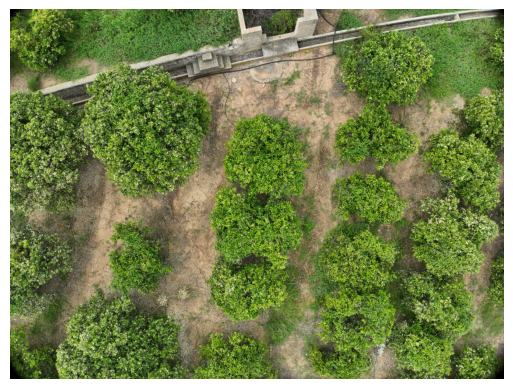

In [29]:
img = Image.open(images[0])
plt.imshow(img)
plt.axis("off")

##Visualize Bounding Boxes

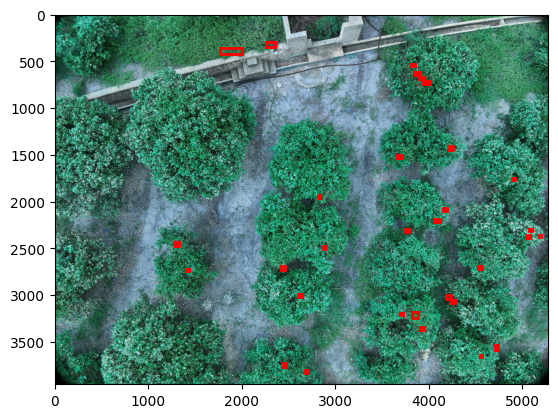

In [30]:
img = cv2.imread(str(images[0]))
h, w = img.shape[:2]

with open(labels[0]) as f:
  lines = f.readlines()

fig, ax = plt.subplots(1)
ax.imshow(img)

for line in lines:
  cls, xc, yc, bw, bh = map(float, line.split())

  x = (xc - bw/2) * w
  y = (yc - bh/2) * h
  bw = bw * w
  bh = bh * h

  rect = patches.Rectangle((x,y),bw,bh,
                             linewidth=2,
                             edgecolor='red',
                             facecolor='none')
  ax.add_patch(rect)

plt.show()

##Dataset Statistics
####Count:
*   number of images
*   number of objects
*   objects per class

In [31]:
class_counts = {}

for label in labels:
  with open(label) as f:
    for line in f:
      cls = int(line.split()[0])
      class_counts[cls] = class_counts.get(cls,0) + 1

print("Total images:", len(images))
print("Total labels:", len(labels))
print("Total objects:", sum(class_counts.values()))
print("Class distribution:", class_counts)

Total images: 1127
Total labels: 1126
Total objects: 50355
Class distribution: {0: 31603, 2: 13905, 3: 326, 4: 274, 1: 4104, 5: 122, 6: 19, 7: 2}


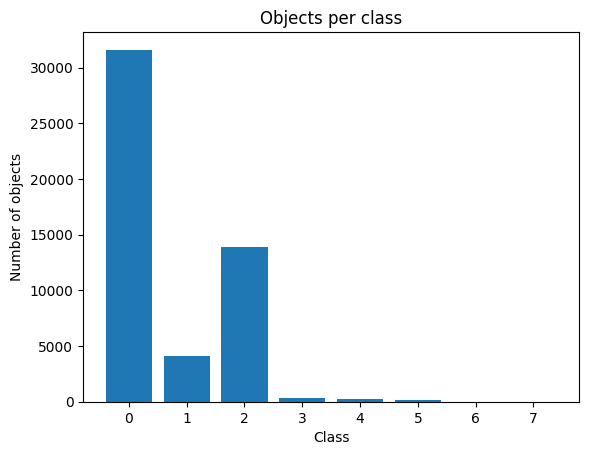

In [32]:
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Number of objects")
plt.title("Objects per class")
plt.show()

##Data Quality Checks
Check for missing labels, empty images, and corrupted images

In [33]:
#Check Missing Labels

missing_labels = []
for img in images:
  label = str(img).replace(".jpg", ".txt")

  if not os.path.exists(label):
    missing_labels.append(img)

print("Images without labels:", len(missing_labels))

Images without labels: 0


In [34]:
#Check Empty Images, Sometimes images exist but contain no objects.
empty_labels = []
for label in labels:
  if os.path.getsize(label) == 0:
    empty_labels.append(label)

print("Empty label files:", len(empty_labels))

Empty label files: 17


In [35]:
#Check Corrupted Images, Some images cannot be opened by Python.

corrupted_images = []
for img_path in images:
  try:
    img = Image.open(img_path)
    img.verify()
  except:
    corrupted_images.append(img_path)

print("Corrupted images:", len(corrupted_images))

Corrupted images: 0


##Data Preprocessing
Image resizing, normalization, convert to YOLO format (if needed)

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

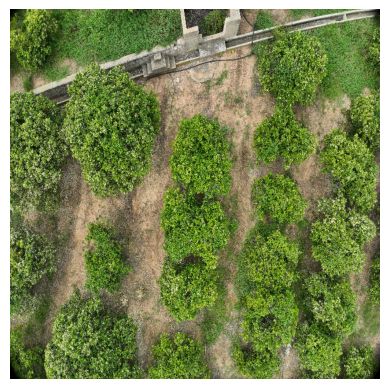

In [36]:
# Resize Images
sample_img = cv2.imread(str(images[0]))
resized_img = cv2.resize(sample_img, (640, 640))

plt.imshow(cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [37]:
#Normalize Image Values
normalized_img = resized_img / 255.0

print("Min val:", normalized_img.min())
print("Max val:", normalized_img.max())

Min val: 0.0
Max val: 1.0


In [38]:
# Verify YOLO Label Format
#Neural networks work better when pixel values are between 0 and 1.

invalid_boxes = []

for label in labels:
  with open(label) as f:
    for line in f:
      parts = line.split()

      if len(parts) != 5:
        invalid_boxes.append(label)
        continue

      _, x, y, w, h = map(float, parts)

      if not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
        invalid_boxes.append(label)

print("Invalid bounding boxes:", len(invalid_boxes))

Invalid bounding boxes: 0


##Train / Validation / Test Split using the standard 70/15/15

In [41]:
train_imgs, temp_imgs = train_test_split(images, test_size=0.30, random_state=42)
val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.50, random_state=42)

print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))
print("Test:", len(test_imgs))

Train: 788
Validation: 169
Test: 170


In [43]:
# Create YOLO Dataset Structure
_path = "./dataset"

if not Path(_path).exists():
  folders = [
    "images/train",
    "images/val",
    "images/test",
    "labels/train",
    "labels/val",
    "labels/test"
  ]

  for folder in folders:
    os.makedirs(os.path.join(_path, folder), exist_ok=True)
    print(f"Created {folder}")
else:
  print("Folder already exist")

Folder already exist


In [44]:
#move Images and labels
def move_files(img_list, split):
  copied = 0
  skipped = 0

  for img_path in img_list:
    img_name = os.path.basename(img_path)
    label_path = str(img_path).replace(".jpg", ".txt").replace(".JPG", ".txt")

    dest_img = f"{_path}/images/{split}/{img_name}"
    dest_label = f"{_path}/labels/{split}/{img_name.replace('.jpg','.txt').replace('.JPG','.txt')}"

    if not os.path.exists(dest_img):
      shutil.copy(img_path, dest_img)
      copied += 1
    else:
      skipped += 1

    if os.path.exists(label_path) and not os.path.exists(dest_label):
      shutil.copy(label_path, dest_label)

  print(f"{split} -> copied: {copied}, skipped: {skipped}")

move_files(train_imgs, "train")
move_files(val_imgs, "val")
move_files(test_imgs, "test")

print('\n')
print("Train images:", len(os.listdir(f"{_path}/images/train")))
print("Validation images:", len(os.listdir(f"{_path}/images/val")))
print("Test images:", len(os.listdir(f"{_path}/images/test")))

train -> copied: 0, skipped: 788
val -> copied: 0, skipped: 169
test -> copied: 0, skipped: 170


Train images: 788
Validation images: 169
Test images: 170


##Data augmentation

(np.float64(-0.5), np.float64(5279.5), np.float64(3955.5), np.float64(-0.5))

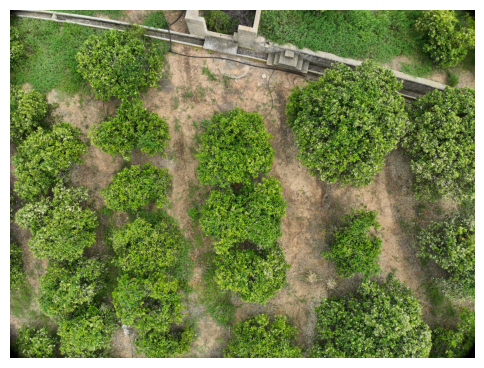

In [48]:
#define augmentation pipeline
transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.4)
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels']
    )
)

# Load images and labels for augmentation
train_img_dir = Path("./dataset/images/train")
train_lbl_dir = Path("./dataset/labels/train")

images = list(train_img_dir.glob("*.jpg")) + list(train_img_dir.glob("*.JPG"))
image_path = images[0]
label_path = train_lbl_dir / (image_path.stem + ".txt")

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

bboxes = []
class_labels = []

with open(label_path) as f:
    for line in f:
        cls, x, y, w, h = map(float, line.split())
        bboxes.append([x, y, w, h])
        class_labels.append(int(cls))

# Apply augmentation
augmented = transform(
    image=image,
    bboxes=bboxes,
    class_labels=class_labels
)

aug_img = augmented["image"]
aug_boxes = augmented["bboxes"]

# Visualize augmented image with bounding boxes
plt.figure(figsize=(6,6))
plt.imshow(aug_img)
plt.axis("off")

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

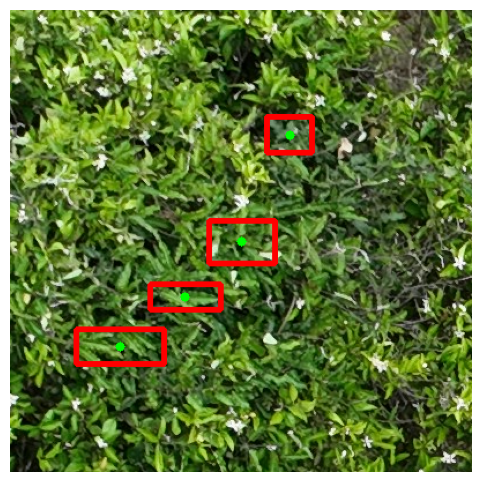

In [49]:
h, w, _ = aug_img.shape

# draw bounding boxes
for box in aug_boxes:
    x, y, bw, bh = box

    x1 = int((x - bw/2) * w)
    y1 = int((y - bh/2) * h)
    x2 = int((x + bw/2) * w)
    y2 = int((y + bh/2) * h)

    cx = int(x * w)
    cy = int(y * h)

    cv2.rectangle(aug_img, (x1, y1), (x2, y2), (255, 0, 0), 3)
    cv2.circle(aug_img, (cx, cy), 4, (0, 255, 0), -1)

# choose one bounding box for zoom visualization
x, y, bw, bh = aug_boxes[0]

cx = int(x * w)
cy = int(y * h)

# crop window size
crop_size = 200

x1 = max(0, cx - crop_size)
y1 = max(0, cy - crop_size)
x2 = min(w, cx + crop_size)
y2 = min(h, cy + crop_size)

zoom_img = aug_img[y1:y2, x1:x2]

# show zoomed region
plt.figure(figsize=(6,6))
plt.imshow(zoom_img)
plt.axis("off")